# 🏢 Administradores de Consorcios de CABA — Análisis exploratorio

Análisis de **5.671 administradores de consorcios** registrados en la Ciudad de Buenos Aires,
a partir de datos públicos del [buscador oficial del GCBA](https://buscador-admin-consorcio.buenosaires.gob.ar/administradores).

> **Privacidad:** este notebook trabaja únicamente con datos **agregados y anonimizados**
> (`data/agregados/`). No se exponen nombres, CUIT ni domicilios. Los agregados se generan con
> `generar_agregados.py` a partir del CSV crudo (local, no versionado).

**Stack:** Python · pandas · matplotlib · seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["font.size"] = 11

DATA = Path("../data/agregados")
IMG = Path("../docs/img")
IMG.mkdir(parents=True, exist_ok=True)

def cargar(nombre):
    return pd.read_csv(DATA / f"{nombre}.csv")

def guardar(fig, nombre):
    fig.savefig(IMG / f"{nombre}.png", bbox_inches="tight", dpi=110)

## 1. Panorama general (KPIs)

In [2]:
estado = cargar("estado_matricula")
onerosidad = cargar("onerosidad")
sanciones = cargar("sanciones")
concentracion = cargar("concentracion")
distrib = cargar("distribucion_consorcios")

total_admins = int(estado["cantidad"].sum())
total_consorcios = int((distrib["cantidad_consorcios"] * distrib["administradores"]).sum())
pct_activa = estado.set_index("estado").loc["ACTIVA", "cantidad"] / total_admins * 100
pct_oneroso = onerosidad.set_index("oneroso").loc["Sí", "cantidad"] / onerosidad["cantidad"].sum() * 100
pct_sancion = sanciones.set_index("tiene_sanciones").loc["Sí", "cantidad"] / total_admins * 100
sin_consorcios = int(distrib.loc[distrib["cantidad_consorcios"] == 0, "administradores"].iloc[0])

print(f"Administradores registrados : {total_admins:,}")
print(f"Consorcios administrados     : {total_consorcios:,}")
print(f"Matrícula ACTIVA             : {pct_activa:.1f}%")
print(f"Cobran honorarios (oneroso)  : {pct_oneroso:.1f}%")
print(f"Con sanciones                : {pct_sancion:.1f}%")
print(f"Sin ningún consorcio a cargo : {sin_consorcios:,} ({sin_consorcios/total_admins*100:.1f}%)")

Administradores registrados : 5,671
Consorcios administrados     : 7,744
Matrícula ACTIVA             : 38.5%
Cobran honorarios (oneroso)  : 79.5%
Con sanciones                : 1.9%
Sin ningún consorcio a cargo : 3,834 (67.6%)


## 2. Estado de las matrículas

Una matrícula puede estar **activa** o **sin actualizar** (no renovó la DDJJ anual).

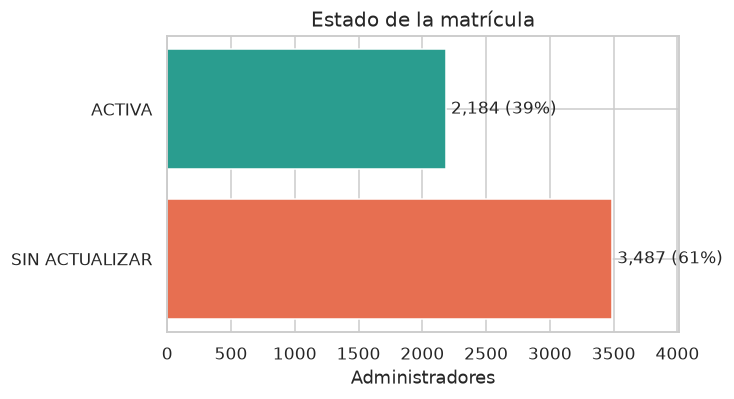

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.5))
colores = {"ACTIVA": "#2a9d8f", "SIN ACTUALIZAR": "#e76f51"}
ax.barh(estado["estado"], estado["cantidad"],
        color=[colores.get(e, "#888") for e in estado["estado"]])
for i, v in enumerate(estado["cantidad"]):
    ax.text(v + 40, i, f"{v:,} ({v/total_admins*100:.0f}%)", va="center")
ax.set_xlabel("Administradores")
ax.set_title("Estado de la matrícula")
ax.margins(x=0.15)
guardar(fig, "estado_matricula")
plt.show()

> 🔎 **Insight:** más del **60% de las matrículas están "sin actualizar"**. El padrón vigente
> es bastante menor al total histórico de inscriptos.

## 3. Concentración del mercado

¿Cómo se reparten los consorcios entre administradores? Esta es la historia más fuerte del dataset.

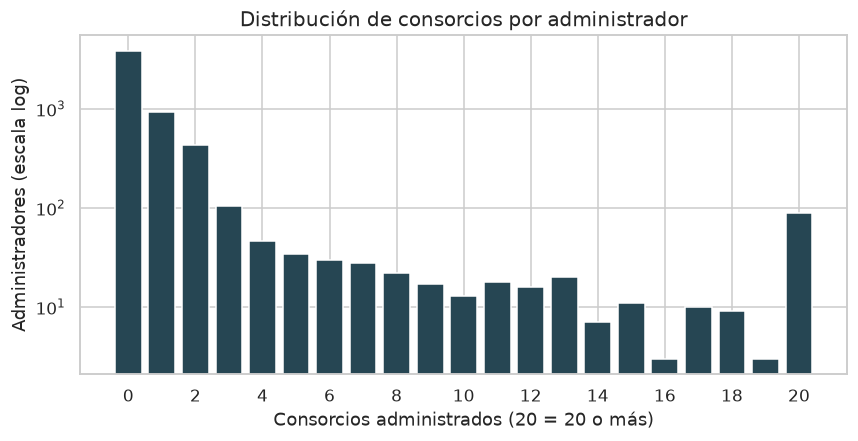

In [4]:
# Distribución (cap a 20 para legibilidad) + cola larga
d = distrib.copy()
d["bucket"] = d["cantidad_consorcios"].clip(upper=20)
agg = d.groupby("bucket")["administradores"].sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(agg.index, agg.values, color="#264653")
ax.set_yscale("log")
ax.set_xlabel("Consorcios administrados (20 = 20 o más)")
ax.set_ylabel("Administradores (escala log)")
ax.set_title("Distribución de consorcios por administrador")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
guardar(fig, "distribucion_consorcios")
plt.show()

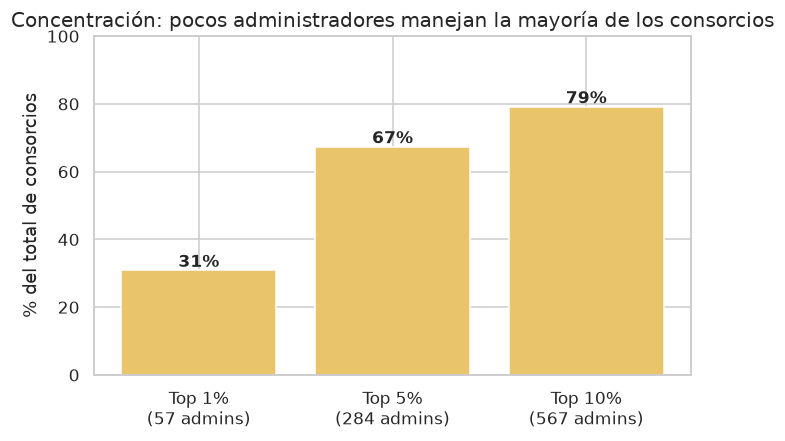

In [5]:
# Curva de concentración tipo Pareto
fig, ax = plt.subplots(figsize=(7, 4))
c = concentracion.dropna(subset=["top_pct"]).copy()
labels = [f"Top {int(p*100)}%\n({n} admins)" for p, n in zip(c["top_pct"], c["top_n_administradores"])]
ax.bar(labels, c["pct_del_total"], color="#e9c46a")
for i, v in enumerate(c["pct_del_total"]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")
ax.set_ylabel("% del total de consorcios")
ax.set_title("Concentración: pocos administradores manejan la mayoría de los consorcios")
ax.set_ylim(0, 100)
guardar(fig, "concentracion")
plt.show()

> 🔎 **Insight:** el mercado está **muy concentrado**. El **top 5%** de los administradores
> (≈284 personas) maneja cerca del **67% de todos los consorcios**, mientras que la enorme mayoría
> administra 0 o 1. El máximo individual supera los **100 consorcios** a cargo.

## 4. Altas de matrículas por año

La fecha de alta nos permite reconstruir la evolución histórica del registro.

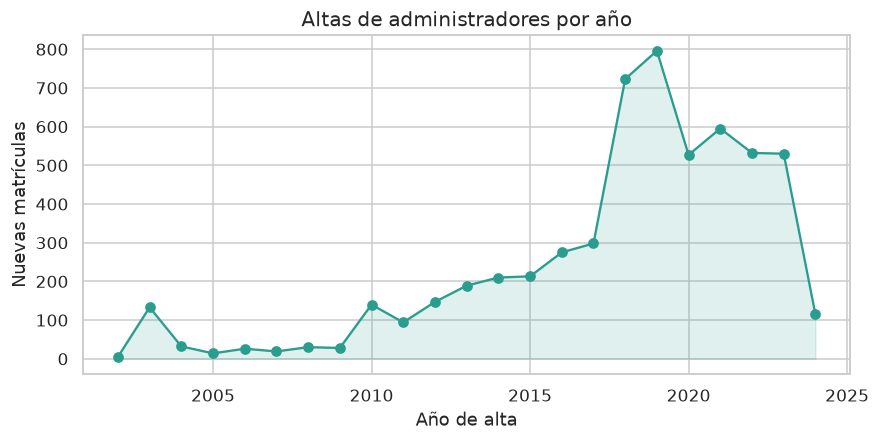

In [6]:
altas = cargar("altas_por_anio")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(altas["anio"], altas["altas"], marker="o", color="#2a9d8f")
ax.fill_between(altas["anio"], altas["altas"], alpha=0.15, color="#2a9d8f")
ax.set_xlabel("Año de alta")
ax.set_ylabel("Nuevas matrículas")
ax.set_title("Altas de administradores por año")
guardar(fig, "altas_por_anio")
plt.show()

> 🔎 **Insight:** las inscripciones se **disparan a partir de 2018** (pico en 2018–2019),
> probablemente por cambios regulatorios, y se mantienen altas pese a la pandemia.

## 5. Onerosidad, sanciones y tipo de persona

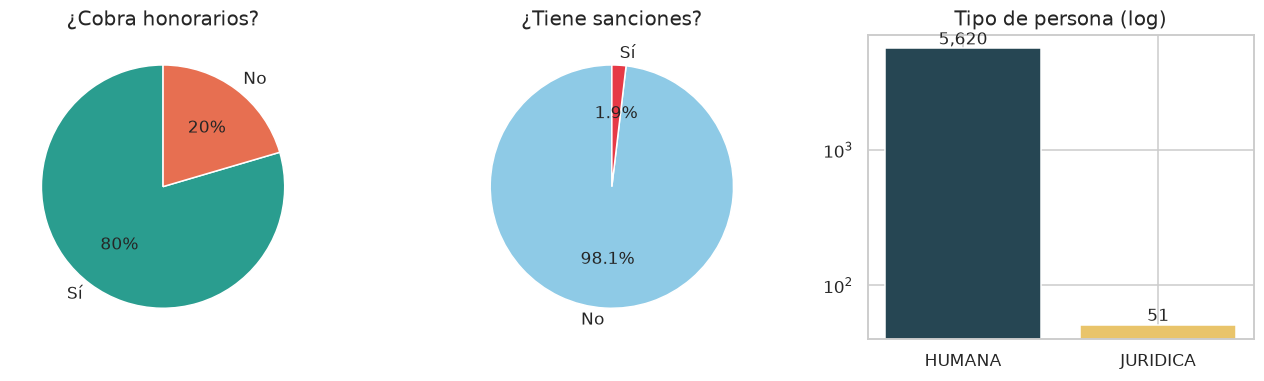

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

o = onerosidad.dropna(subset=["oneroso"])
axes[0].pie(o["cantidad"], labels=o["oneroso"], autopct="%1.0f%%",
            colors=["#2a9d8f", "#e76f51"], startangle=90)
axes[0].set_title("¿Cobra honorarios?")

s = sanciones
axes[1].pie(s["cantidad"], labels=s["tiene_sanciones"], autopct="%1.1f%%",
            colors=["#8ecae6", "#e63946"], startangle=90)
axes[1].set_title("¿Tiene sanciones?")

tp = cargar("tipo_persona")
axes[2].bar(tp["tipo_persona"], tp["cantidad"], color=["#264653", "#e9c46a"])
axes[2].set_yscale("log")
axes[2].set_title("Tipo de persona (log)")
for i, v in enumerate(tp["cantidad"]):
    axes[2].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
guardar(fig, "perfil")
plt.show()

> 🔎 **Insight:** ~**80% cobra honorarios**, solo **1,9% registra sanciones**, y la actividad
> es casi totalmente de **personas humanas** (las sociedades son una minoría).

## 6. Estimación de género (por prefijo de CUIT)

Convención AFIP: CUIT que empieza en 20/23/24 ≈ masculino, 27 ≈ femenino. Es una **estimación
agregada** — no se expone ningún CUIT individual.

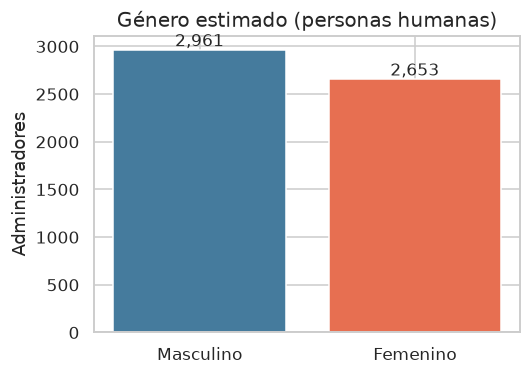

In [8]:
g = cargar("genero_estimado")
g = g[g["genero_estimado"] != "Indeterminado"]
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(g["genero_estimado"], g["cantidad"], color=["#457b9d", "#e76f51"])
for i, v in enumerate(g["cantidad"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_ylabel("Administradores")
ax.set_title("Género estimado (personas humanas)")
guardar(fig, "genero_estimado")
plt.show()

> 🔎 **Insight:** la actividad está **bastante equilibrada por género** (~53% / 47%),
> algo poco común en otros registros profesionales.

## 7. Conclusiones

- **Padrón inflado:** >60% de las matrículas están sin actualizar y ~68% no administra ningún consorcio.
- **Alta concentración:** el top 5% maneja ~67% de los consorcios (uno solo supera los 100).
- **Crecimiento reciente:** boom de inscripciones desde 2018.
- **Bajo nivel de sanciones** (1,9%) y mayoría de **personas humanas** que **cobran honorarios**.

---
*Datos públicos del GCBA, agregados y anonimizados. Análisis con fines educativos.*